In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
df=pd.read_csv(r'C:\Users\Praveen\OneDrive\Desktop\FraudShield-ML\data\Synthetic Financial Datasets For Fraud Detection.csv')

In [107]:
df.shape

(6362620, 11)

In [108]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [109]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [111]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [112]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [113]:
df["nameDest"].str[0].value_counts()

nameDest
C    4211125
M    2151495
Name: count, dtype: int64

In [114]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [115]:
df.duplicated().sum()

0

In [116]:
balance_cols = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]

(df[balance_cols] < 0).sum()

amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
dtype: int64

In [117]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [118]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [119]:
pd.crosstab(df["type"], df["isFraud"])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


In [120]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [121]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [122]:
df.shape

(6362620, 11)

In [ ]:
pd.crosstab(
    df["type"],
    df["isFraud"],
    normalize="index"
) * 100a

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


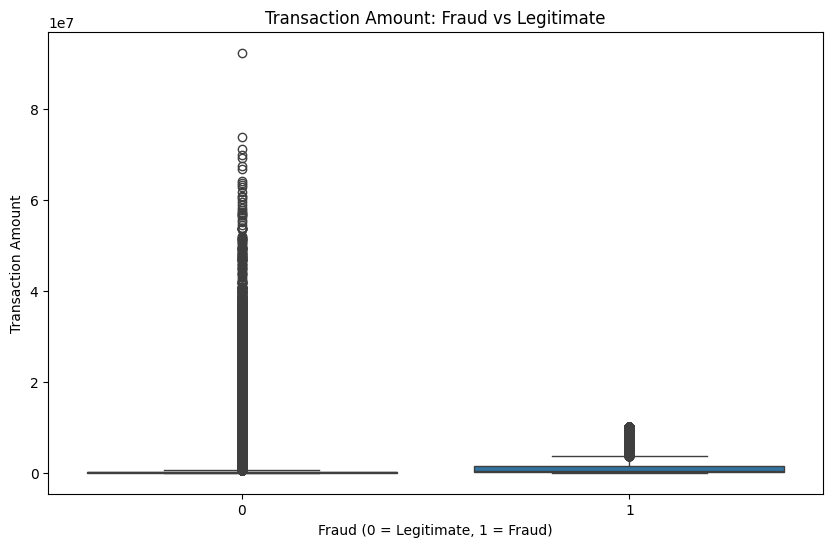

In [124]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="isFraud",
    y="amount",
    data=df
)

plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.title("Transaction Amount: Fraud vs Legitimate")
plt.show()

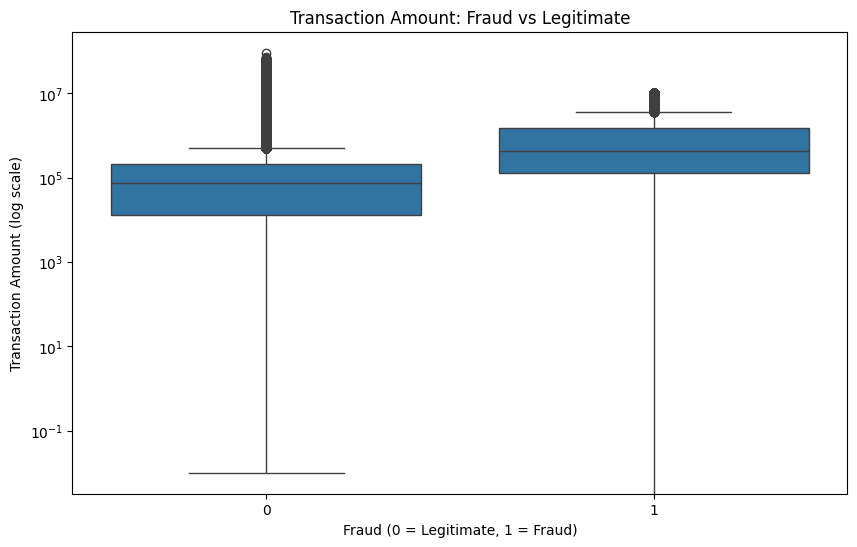

In [125]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="isFraud",
    y="amount",
    data=df
)

plt.yscale("log")

plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount (log scale)")
plt.title("Transaction Amount: Fraud vs Legitimate")

plt.show()

In [126]:
df.groupby("isFraud")[["oldbalanceOrg", "newbalanceOrig"]].median()

,oldbalanceOrg,newbalanceOrig
isFraud,,
0,14069.00,0.0
1,438983.45,0.0


In [222]:
df.groupby("isFraud")[["oldbalanceDest", "newbalanceDest"]].mean()

,oldbalanceDest,newbalanceDest
isFraud,,
0,1.101421e+06,1.224926e+06
1,5.442496e+05,1.279708e+06


In [128]:
df["dest_balance_change"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

In [129]:
df["org_balance_change"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

In [130]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,dest_balance_change,org_balance_change
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0.0,9839.64
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0.0,1864.28
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0.0,181.00
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,-21182.0,181.00
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0.0,11668.14


In [131]:
# df.drop('old_balance_change',axis=1).head()

In [132]:
df.groupby("isFraud")["org_balance_change"].median()

isFraud
0         0.00
1    436317.49
Name: org_balance_change, dtype: float64

In [133]:
df.groupby("isFraud")["dest_balance_change"].median()

isFraud
0    0.0
1    0.0
Name: dest_balance_change, dtype: float64

In [134]:
df.groupby("isFraud")["dest_balance_change"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,123504.809994,8.104223e+05,-13060826.21,0.0,0.0,148982.64,1.056878e+08
1,8213.0,735457.998071,1.856984e+06,-315226.07,0.0,0.0,445257.43,1.491511e+07


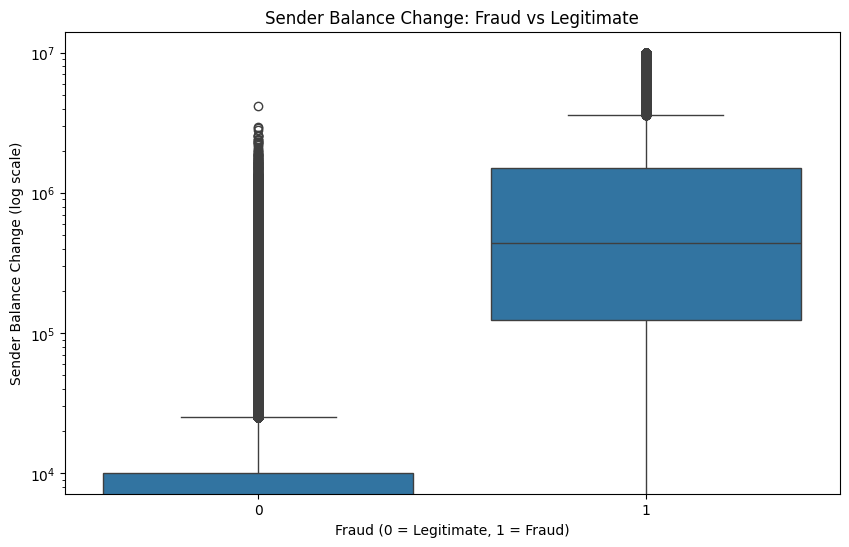

In [135]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="isFraud",
    y="org_balance_change",
    data=df
)

plt.yscale("log")

plt.xlabel("Fraud (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Sender Balance Change (log scale)")
plt.title("Sender Balance Change: Fraud vs Legitimate")

plt.show()

In [136]:
df["step"].describe()

count    6.362620e+06
mean     2.433972e+02
std      1.423320e+02
min      1.000000e+00
25%      1.560000e+02
50%      2.390000e+02
75%      3.350000e+02
max      7.430000e+02
Name: step, dtype: float64

In [ ]:
df.groupby("step")["isFraud"].sum().describe()  

count    743.000000
mean      11.053836
std        4.998631
min        0.000000
25%        8.000000
50%       10.000000
75%       14.000000
max       40.000000
Name: isFraud, dtype: float64

In [138]:
fraud_by_step = (
    df.groupby("step")["isFraud"]
      .mean()
      .mul(100)
)

fraud_by_step.describe()

count    743.000000
mean      43.925264
std       48.956185
min        0.000000
25%        0.074895
50%        1.915709
75%      100.000000
max      100.000000
Name: isFraud, dtype: float64

In [139]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [140]:
fraud_by_step.head()

step
1    0.590842
2    0.788955
3    0.724638
4    1.769912
5    0.902256
Name: isFraud, dtype: float64

In [141]:
fraud_by_step.quantile(0.5)

1.9157088122605364

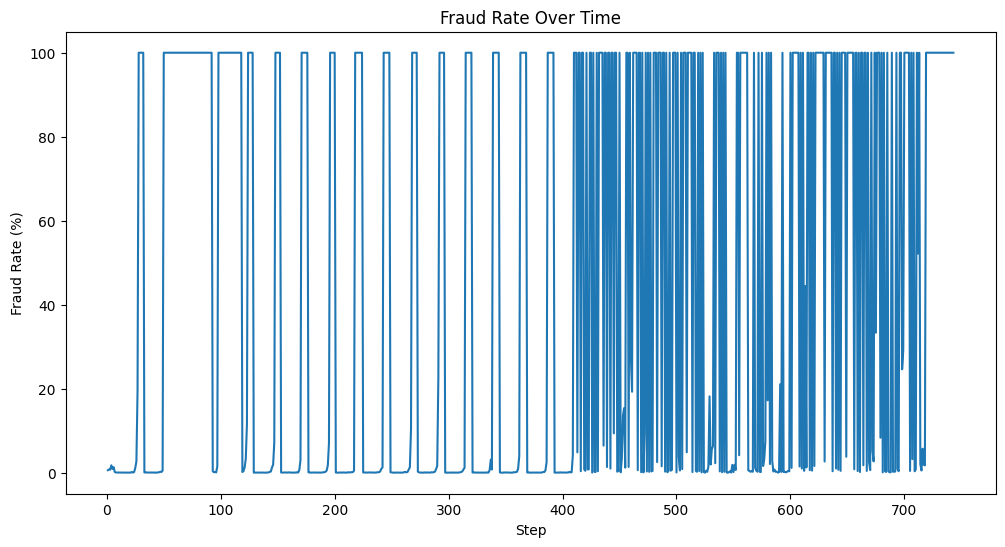

In [142]:
plt.figure(figsize=(12, 6))

plt.plot(fraud_by_step.index, fraud_by_step.values)

plt.xlabel("Step")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate Over Time")

plt.show()

In [ ]:
df["time_period"] = (df["step"] // 100) * 100
df['time_period'].iloc[5360922]

300

In [144]:
fraud_by_period = (
    df.groupby("time_period")["isFraud"]
      .mean()
      .mul(100)
)

fraud_by_period.head()

time_period
0      0.111750
100    0.080293
200    0.069084
300    0.062323
400    0.365847
Name: isFraud, dtype: float64

In [145]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,dest_balance_change,org_balance_change,time_period
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0.0,9839.64,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0.0,1864.28,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0.0,181.00,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,-21182.0,181.00,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0.0,11668.14,0


In [146]:
df.groupby("type")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
CASH_IN,1399284.0,168920.242004,1.265083e+05,0.04,70510.1825,143427.710,239899.0875,1915267.90
CASH_OUT,2237500.0,176273.964346,1.753297e+05,0.00,72669.6500,147072.185,246539.4775,10000000.00
DEBIT,41432.0,5483.665314,1.331854e+04,0.55,1500.1800,3048.990,5479.1750,569077.51
PAYMENT,2151495.0,13057.604660,1.255645e+04,0.02,4383.8200,9482.190,17561.2200,238637.98
TRANSFER,532909.0,910647.009645,1.879574e+06,2.60,215905.3500,486308.390,974958.0000,92445516.64


In [147]:
df.groupby(["type", "isFraud"])["amount"].describe()

count          mean           std    min          25%  \
type     isFraud                                                              
CASH_IN  0        1399284.0  1.689202e+05  1.265083e+05   0.04   70510.1825   
CASH_OUT 0        2233384.0  1.739172e+05  1.312222e+05   0.01   72627.6900   
         1           4116.0  1.455103e+06  2.393842e+06   0.00  125464.4500   
DEBIT    0          41432.0  5.483665e+03  1.331854e+04   0.55    1500.1800   
PAYMENT  0        2151495.0  1.305760e+04  1.255645e+04   0.02    4383.8200   
TRANSFER 0         528812.0  9.062290e+05  1.874155e+06   2.60  216570.7650   
         1           4097.0  1.480892e+06  2.414890e+06  63.80  128417.9600   

                         50%           75%          max  
type     isFraud                                         
CASH_IN  0        143427.710  2.398991e+05   1915267.90  
CASH_OUT 0        146946.560  2.461812e+05   2847566.62  
         1        435516.905  1.500761e+06  10000000.00  
DEBIT    0          3048.990  5.479175e+03    569077.51  
PAYMENT  0          9482.190  1.756122e+04    238637.98  
TRANSFER 0        486521.910  9.727336e+05  92445516.64  
         1        445705.760  1.534985e+06  10000000.00

In [148]:
df[df["type"] == "CASH_OUT"].groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,2233384.0,1.739172e+05,1.312222e+05,0.01,72627.69,146946.560,246181.18,2847566.62
1,4116.0,1.455103e+06,2.393842e+06,0.00,125464.45,435516.905,1500761.03,10000000.00


In [149]:
df["isFlaggedFraud"].value_counts()

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

In [150]:
pd.crosstab(df["isFlaggedFraud"], df["isFraud"])

isFraud,0,1
isFlaggedFraud,,
0,6354407,8197
1,0,16


In [151]:
numeric_cols = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "org_balance_change",
    "dest_balance_change"
]

corr = df[numeric_cols].corr()

corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,org_balance_change,dest_balance_change
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.102337,0.845964
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,-0.220297,-0.087032
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.267750,-0.094456
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.047460,0.232316
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,-0.006451,0.436191
org_balance_change,0.102337,-0.220297,-0.267750,-0.047460,-0.006451,1.000000,0.169292
dest_balance_change,0.845964,-0.087032,-0.094456,0.232316,0.436191,0.169292,1.000000


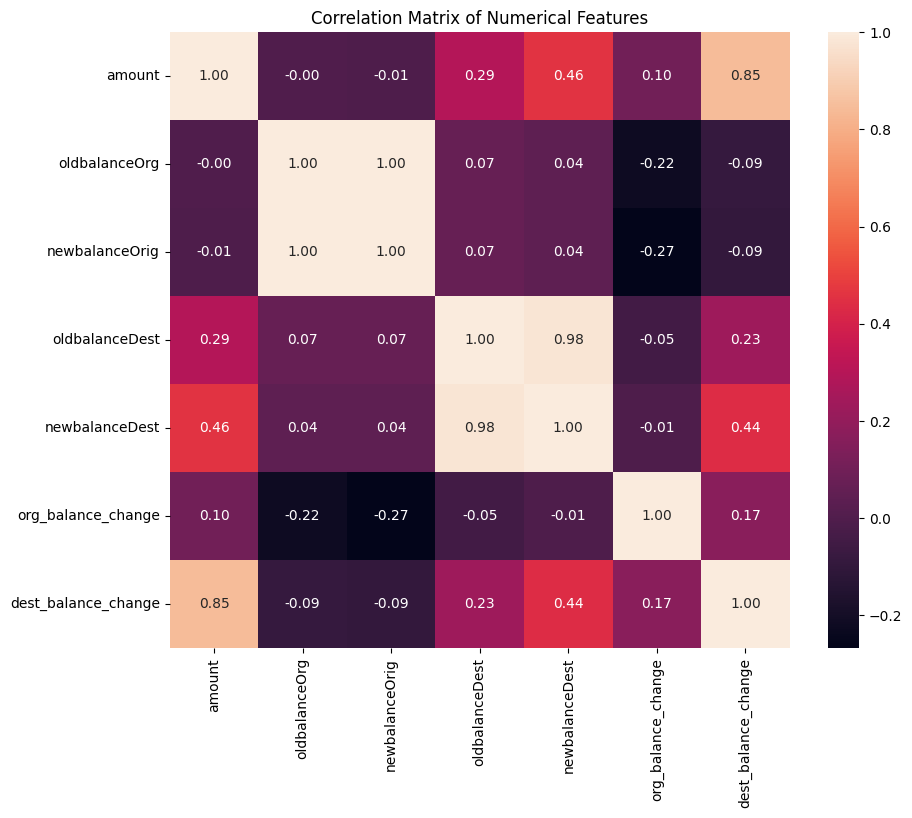

In [152]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [153]:
df["nameOrig"].nunique()

6353307

In [154]:
df["nameOrig"].value_counts().describe()

count    6.353307e+06
mean     1.001466e+00
std      3.832002e-02
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      3.000000e+00
Name: count, dtype: float64

In [155]:
drop_cols = ["nameOrig", "nameDest"]

In [156]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,dest_balance_change,org_balance_change,time_period
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,0.0,9839.64,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,0.0,1864.28,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,0.0,181.00,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,-21182.0,181.00,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,0.0,11668.14,0


In [157]:
X = df.drop(['nameOrig','nameDest','isFraud','time_period'],axis=1)
y = df["isFraud"]

In [158]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [159]:
print("Training:")
print(y_train.value_counts())

print("\nTesting:")
print(y_test.value_counts())

Training:
isFraud
0    5083526
1       6570
Name: count, dtype: int64

Testing:
isFraud
0    1270881
1       1643
Name: count, dtype: int64


In [160]:
print("\nTraining percentage:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting percentage:")
print(y_test.value_counts(normalize=True) * 100)


Training percentage:
isFraud
0    99.870926
1     0.129074
Name: proportion, dtype: float64

Testing percentage:
isFraud
0    99.870887
1     0.129113
Name: proportion, dtype: float64


In [161]:
class_counts = y_train.value_counts()

legitimate = class_counts[0]
fraud = class_counts[1]

print("Legitimate:", legitimate)
print("Fraud:", fraud)
print("Imbalance ratio:", legitimate / fraud)

Legitimate: 5083526
Fraud: 6570
Imbalance ratio: 773.7482496194825


In [162]:
X_train = pd.get_dummies(X_train, columns=["type"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["type"], drop_first=True)


In [ ]:
X_train.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,dest_balance_change,org_balance_change,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
292779,15,9914.74,44248.00,34333.26,0.00,0.00,0,0.00,9914.74,False,False,True,False
499763,20,6854.53,0.00,0.00,0.00,0.00,0,0.00,0.00,False,False,True,False
2970411,231,361211.80,0.00,0.00,489745.16,850956.95,0,361211.79,0.00,True,False,False,False
3137549,236,7083.51,0.00,0.00,0.00,0.00,0,0.00,0.00,False,False,True,False
1500682,143,218019.51,13045685.58,13263705.09,2438123.98,2220104.47,0,-218019.51,-218019.51,False,False,False,False


In [164]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [165]:
X_test.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,dest_balance_change,org_balance_change,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
4051353,300,890577.21,218.00,0.00,0.00,890577.21,0,890577.21,218.00,False,False,False,True
5746321,399,97734.24,2096258.84,2193993.08,320136.00,222401.76,0,-97734.24,-97734.24,False,False,False,False
6361797,718,5907.41,315.00,0.00,0.00,0.00,0,0.00,315.00,False,False,True,False
2247309,186,187696.30,11057.00,0.00,1798095.21,1985791.51,0,187696.30,11057.00,True,False,False,False
4692207,331,82646.52,0.00,0.00,1047805.87,1130452.39,0,82646.52,0.00,True,False,False,False


In [166]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [167]:
X_train.shape

(5090096, 13)

In [168]:
X_test.shape

(1272524, 13)

In [169]:
numeric_cols = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "org_balance_change",
    "dest_balance_change"
]

In [170]:
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [171]:
X_train.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud,dest_balance_change,org_balance_change,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
292779,-1.604574,-0.282169,-0.273409,-0.280706,-0.323308,-0.333104,0,-0.153404,0.212249,False,False,True,False
499763,-1.569442,-0.287248,-0.288733,-0.292451,-0.323308,-0.333104,0,-0.153404,0.144618,False,False,True,False
2970411,-0.086865,0.300938,-0.288733,-0.292451,-0.179414,-0.101671,0,0.291988,0.144618,True,False,False,False
3137549,-0.051733,-0.286868,-0.288733,-0.292451,-0.323308,-0.333104,0,-0.153404,0.144618,False,False,True,False
1500682,-0.705191,0.063257,4.229095,4.244653,0.393047,0.270692,0,-0.422232,-1.342539,False,False,False,False


In [172]:
X_train.shape


(5090096, 13)

In [173]:
X_test.shape

(1272524, 13)

In [174]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [175]:
y_pred = lr.predict(X_test)

In [176]:
from sklearn.metrics import confusion_matrix,classification_report

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1211926   58955]
 [     48    1595]]


In [177]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98   1270881
           1       0.03      0.97      0.05      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.96      0.51   1272524
weighted avg       1.00      0.95      0.98   1272524



In [187]:
y_prob = lr.predict_proba(X_test)[:, 1]

In [ ]:

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for threshold in thresholds:
    
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    
    print(
        threshold,
        "Precision:", round(precision, 3),
        "Recall:", round(recall, 3),
        "F1:", round(f1, 3)
    )

0.1 Precision: 0.007 Recall: 0.999 F1: 0.014
0.2 Precision: 0.01 Recall: 0.999 F1: 0.019
0.3 Precision: 0.013 Recall: 0.995 F1: 0.025
0.4 Precision: 0.018 Recall: 0.985 F1: 0.035
0.5 Precision: 0.026 Recall: 0.971 F1: 0.051
0.6 Precision: 0.038 Recall: 0.954 F1: 0.073
0.7 Precision: 0.054 Recall: 0.92 F1: 0.103
0.8 Precision: 0.085 Recall: 0.88 F1: 0.155
0.9 Precision: 0.159 Recall: 0.788 F1: 0.265


In [189]:
from sklearn.metrics import confusion_matrix

threshold = 0.9

y_pred_09 = (y_prob >= threshold).astype(int)

cm_09 = confusion_matrix(y_test, y_pred_09)

print(cm_09)

[[1264045    6836]
 [    349    1294]]


In [190]:
print(classification_report(y_test,y_pred_09))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.16      0.79      0.26      1643

    accuracy                           0.99   1272524
   macro avg       0.58      0.89      0.63   1272524
weighted avg       1.00      0.99      1.00   1272524



In [191]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = []

for threshold in np.arange(0.50, 1.00, 0.01):

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    results.append([
        threshold,
        precision,
        recall,
        f1
    ])

results_df = pd.DataFrame(
    results,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

results_df

,Threshold,Precision,Recall,F1
0,0.50,0.026342,0.970785,0.051292
1,0.51,0.027449,0.970785,0.053388
2,0.52,0.028519,0.969568,0.055409
3,0.53,0.029647,0.968351,0.057533
4,0.54,0.030744,0.966525,0.059592
5,0.55,0.031912,0.966525,0.061784
6,0.56,0.033085,0.964090,0.063974
7,0.57,0.034232,0.961656,0.066110
8,0.58,0.035558,0.961656,0.068581
9,0.59,0.036682,0.957395,0.070657


In [192]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

ROC-AUC: 0.9940871862482149
PR-AUC: 0.6003006666886861


In [196]:
from cr import evaluate_model

In [197]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

dt.fit(X_train, y_train)

evaluate_model(dt, X_test, y_test)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.89      0.87      0.88      1643

    accuracy                           1.00   1272524
   macro avg       0.94      0.94      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524

Confusion Matrix:
[[1270703     178]
 [    211    1432]]


In [198]:
from sklearn.ensemble import RandomForestClassifier

In [199]:
rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

In [200]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [201]:
evaluate_model(rf, X_test, y_test)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.97      0.81      0.88      1643

    accuracy                           1.00   1272524
   macro avg       0.99      0.90      0.94   1272524
weighted avg       1.00      1.00      1.00   1272524

Confusion Matrix:
[[1270847      34]
 [    317    1326]]


In [206]:
# from sklearn.ensemble import GradientBoostingClassifier

# gb = GradientBoostingClassifier(
#     random_state=42
# )

from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42
)

In [207]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

In [208]:
# gb.fit(
#     X_train,
#     y_train,
#     sample_weight=sample_weights
# )

hgb.fit(
    X_train,
    y_train,
    sample_weight=sample_weights
)

HistGradientBoostingClassifier(random_state=42)

In [209]:
evaluate_model(hgb, X_test, y_test)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.25      0.99      0.40      1643

    accuracy                           1.00   1272524
   macro avg       0.62      1.00      0.70   1272524
weighted avg       1.00      1.00      1.00   1272524

Confusion Matrix:
[[1265895    4986]
 [      9    1634]]


In [211]:
from xgboost import XGBClassifier

In [212]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    scale_pos_weight=773.75,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

In [213]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [214]:
evaluate_model(xgb, X_test, y_test)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.20      0.99      0.34      1643

    accuracy                           0.99   1272524
   macro avg       0.60      0.99      0.67   1272524
weighted avg       1.00      0.99      1.00   1272524

Confusion Matrix:
[[1264444    6437]
 [      9    1634]]


In [215]:
import joblib
import os

# Make sure models folder exists
os.makedirs("../models", exist_ok=True)

# -----------------------------
# SAVE TRAINED MODELS
# -----------------------------

joblib.dump(lr, "../models/logistic_regression.pkl")
print("Saved: logistic_regression.pkl")

joblib.dump(dt, "../models/decision_tree.pkl")
print("Saved: decision_tree.pkl")

joblib.dump(rf, "../models/random_forest.pkl")
print("Saved: random_forest.pkl")

joblib.dump(xgb, "../models/xgboost.pkl")
print("Saved: xgboost.pkl")


# Histogram Gradient Boosting
if "hgb" in globals():
    joblib.dump(hgb, "../models/hist_gradient_boosting.pkl")
    print("Saved: hist_gradient_boosting.pkl")


# Standard Gradient Boosting
if "gb" in globals():
    joblib.dump(gb, "../models/gradient_boosting.pkl")
    print("Saved: gradient_boosting.pkl")


# -----------------------------
# SAVE SCALER
# -----------------------------

joblib.dump(scaler, "../models/scaler.pkl")
print("Saved: scaler.pkl")


# -----------------------------
# SAVE FEATURE COLUMNS
# -----------------------------

joblib.dump(
    X_train.columns.tolist(),
    "../models/feature_columns.pkl"
)
print("Saved: feature_columns.pkl")


print("\nAll required objects saved successfully!")

Saved: logistic_regression.pkl
Saved: decision_tree.pkl
Saved: random_forest.pkl
Saved: xgboost.pkl
Saved: hist_gradient_boosting.pkl
Saved: gradient_boosting.pkl
Saved: scaler.pkl
Saved: feature_columns.pkl

All required objects saved successfully!


In [221]:
import os

print(os.listdir("../models"))

['decision_tree.pkl', 'feature_columns.pkl', 'gradient_boosting.pkl', 'hist_gradient_boosting.pkl', 'logistic_regression.pkl', 'random_forest.pkl', 'scaler.pkl', 'xgboost.pkl']
